# OPERA DISP-S1, part 2: analysing the stack with MintPy

Part 1 left us with `corcoran-stack.nc`: a rebased, spatially-referenced displacement time
series. 

Here we convert the data and metadata to a format that MintPy can understand for further analysis.

The `opera-utils` has a `disp` subpackage with a function to do this.

In [1]:
from pathlib import Path
import shutil
import h5py
import numpy as np

import utils
from opera_utils.disp.mintpy import disp_nc_to_mintpy

FRAME_ID = 38502

## Download geometry layers

MintPy needs incidence and azimuth angles to reproject line-of-sight displacement. It also can use a DEM for hillshade plotting. 
For DISP-S1 those come from a separate ASF collection, `OPERA_L3_DISP-S1-STATIC_V1`. These are static per frame over time. Each is a GeoTIFF with the east, north, and vertical LOS unit vectors. There is also a layover and shadow mask at the same posting as the UTM grid.

In [2]:
utils.download_static_layers(
    FRAME_ID, like=sorted(Path("subsets").glob("*.nc"))[0], output_dir="geometry"
)

Skipped (exists): geometry/F38502_los_enu.tif
Skipped (exists): geometry/F38502_dem.tif
Skipped (exists): geometry/F38502_layover_shadow_mask.tif


PosixPath('geometry')

## Convert to MintPy

`disp_nc_to_mintpy` needs the rebased stack, one of the original granules (for metadata that
the stack does not carry), and the geometry directory.

There is a mode that makes `timeseries.h5` an HDF5 "virtual dataset" (`virtual=True`), which basically creates pointers back to the original NetCDF files. This saves a lot of disk space for large analyses, but it is sensitive to relative paths and can be fiddly. Copy the data for portability.

In [3]:
disp_nc_to_mintpy(
    Path("corcoran-stack.nc"),
    sample_disp_nc=sorted(Path("subsets").glob("*.nc"))[0],
    geometry_dir=Path("geometry"),
    outdir=Path("mintpy"),
)

Done with timeseries.h5 (copied data)
Done with avgSpatialCoh.h5
reliability products: timeseries_density.h5 & recommended_mask_90thresh.h5
Done with velocity.h5
Created geometryGeo.h5.

All done : /home/jovyan/2026-isceplus/5.2_OPERA_displacement_products/mintpy



In [4]:
for f in sorted(Path("mintpy").glob("*.h5")):
    print(f"{f.name:35s} {f.stat().st_size / 1e6:8.1f} MB")

avgSpatialCoh.h5                         6.6 MB
geometryGeo.h5                           7.8 MB
recommended_mask_90thresh.h5             0.4 MB
timeseries.h5                         5059.7 MB
timeseries_density.h5                    2.4 MB
timeseries_filled.h5                  3895.3 MB
timeseries_ref.h5                     3895.3 MB
velocity.h5                             17.2 MB
velocity_seasonal.h5                   139.3 MB


Descriptions of files:

| file | contents |
|---|---|
| `timeseries.h5` | the geocoded LOS displacement stack (in meters) |
| `velocity.h5` | an average linear velocit (in m/yr). Note that this was not fit using Mintpy, but could be replcaed |
| `geometryGeo.h5` | incidence/azimuth angles, DEM, layover-shadow mask |
| `avgSpatialCoh.h5` | average temporal coherence, used for reference-point picking |
| `recommended_mask_90thresh.h5` | pixels flagged "good" in at least 90% of epochs |
| `timeseries_density.h5` | how many epochs each pixel was valid in |


## Using MintPy's plotting functions


Note that the units on `-v` for MintPy displays velocity are in cm/year, where is the DISP products use m/year.

In [5]:
%%bash
view.py mintpy/velocity.h5 velocity \
    --mask mintpy/recommended_mask_90thresh.h5 \
    --dem mintpy/geometryGeo.h5 \
    -v -20 20 -c RdBu_r \
    --figsize 8 7 --nodisplay -o velocity_corcoran.png

run view.py in MintPy version 1.6.2, date 2025-07-07
input file is velocity file: /home/jovyan/2026-isceplus/5.2_OPERA_displacement_products/mintpy/velocity.h5 in float32 format
file size in y/x: (2095, 2348)
input dataset: "['velocity']"
turning glob search OFF for velocity file
num of datasets in file velocity.h5: 1
datasets to exclude (0):
[]
datasets to display (1):
['velocity']
data   coverage in y/x: (0, 0, 2348, 2095)
subset coverage in y/x: (0, 0, 2348, 2095)
data   coverage in lat/lon: (244560.0, 4037640.0, 315000.0, 3974790.0)
subset coverage in lat/lon: (244560.0, 4037640.0, 315000.0, 3974790.0)
------------------------------------------------------------------------
area exceed 2000 pixels, turn off default DEM contour display
colormap: RdBu_r
figure title: velocity
read mask from file: recommended_mask_90thresh.h5
reading data ...
masking data
data    range: [np.float32(-22.901001), np.float32(5.851565)] cm/year
display range: [-20.0, 20.0] cm/year
reading DEM: geometryGeo

### Pick your own reference point

Part 1 used `--reference-method BORDER`, the median of the frame edge. That is a reasonable default for crops around one localized uplift or subsidence feature, but is not always a good hoice. MintPy lets you move the reference after the fact, which is the exercise from homework 9.

Pick something towards the eastern edge of the AOI, up against the Sierra foothills and off the compacting aquifer. It must be inside your downloaded box, or MintPy will refuse with "input reference point is OUT of data coverage!"

In [6]:
%%bash
reference_point.py mintpy/timeseries.h5 --lat 36.30 --lon -119.10 \
    -o mintpy/timeseries_ref.h5

--------------------------------------------------
input reference point in lat/lon: (36.3, -119.1)
input reference point in y/x: (612, 2229)
--------------------------------------------------
calculating the temporal average of timeseries file: mintpy/timeseries.h5
reading timeseries data from file: mintpy/timeseries.h5 ...
writing the referenced data into file: mintpy/timeseries_ref.h5
delete exsited file: mintpy/timeseries_ref.h5
create HDF5 file: mintpy/timeseries_ref.h5 with w mode
create dataset /timeseries of float32    in size of (193, 2095, 2348)    with compression=None
create dataset /bperp      of float32    in size of (193,)     with compression=None
create dataset /date       of |S8        in size of (193,)     with compression=None
finished writing to mintpy/timeseries_ref.h5


Compare the velocity map before and after: the field should shift by some constant value.

This step is also helps certain MintPy steps which expect `REF_X`/`REF_Y` (since, with `BORDER` or `HIGH_COHERENCE`, there is no single reference pixel. Some InSAR users do not like this "distributed reference"; it is a contentious topic!)

## Fitting other time series functions

We saw that the Central Valley subsidence is nonlinear, and even the seasonal sinusoids can vary wildly from year to yeaer.
We did a simple `polyfit` in Part 1, but one of the main benefits of using `timeseries2velocity.py` is to fit other terms.

One caveat is that it will reject a pixel that is `nan` in some epochs.
Source granules contain a small number of those pixels even when no quality mask is applied during rebasing. 
Below, we fill with zeros, which MintPy skips. These pixels can be masked out after manually.

In [7]:
shutil.copy("mintpy/timeseries_ref.h5", "mintpy/timeseries_filled.h5")
with h5py.File("mintpy/timeseries_filled.h5", "r+") as f:
    timeseries = f["timeseries"]
    num_partial = 0
    for row_start in range(0, timeseries.shape[1], 64):
        rows = slice(row_start, row_start + 64)
        block = timeseries[:, rows, :]
        partial = (~np.isfinite(block)).any(axis=0)
        num_partial += int(partial.sum())
        if partial.any():
            block[:, partial] = 0
            timeseries[:, rows, :] = block
print(f"zeroed {num_partial} partially-NaN pixels")

zeroed 63852 partially-NaN pixels


In [8]:
%%bash
timeseries2velocity.py mintpy/timeseries_filled.h5 \
    --periodic 1.0 \
    -o mintpy/velocity_seasonal.h5

open timeseries file: timeseries_filled.h5
--------------------------------------------------
dates from input file: 193
['20191019', '20200105', '20200111', '20200117', '20200123', '20200129', '20200204', '20200210', '20200216', '20200222', '20200228', '20200305', '20200311', '20200317', '20200323', '20200329', '20200404', '20200410', '20200416', '20200422', '20200428', '20200504', '20200510', '20200516', '20200522', '20200528', '20200603', '20200609', '20200615', '20200621', '20200627', '20200703', '20200709', '20200715', '20200721', '20200727', '20200802', '20200808', '20200814', '20200820', '20200826', '20200901', '20200907', '20200913', '20200919', '20200925', '20201001', '20201007', '20201013', '20201019', '20201025', '20201031', '20201106', '20201112', '20201118', '20201124', '20201130', '20201206', '20201212', '20201218', '20201224', '20201230', '20210111', '20210117', '20210123', '20210129', '20210204', '20210210', '20210216', '20210222', '20210228', '20210306', '20210312', '2

The output carries `velocity`, `velocityStd`, and the amplitude/phase of the annual term.
Annual motion can reflect pumping and recharge, but it can also contain residual atmosphere
and reference effects. Separating elastic from inelastic aquifer response requires more
than this one fit - groundwater levels are an important independent check.

## Homework: compare against the ASF displacement portal

Open the [OPERA displacement portal](https://displacement.asf.alaska.edu/#/?dispOverview=VEL&zoom=8.812&center=-119.934,36.430)
at the bounds above and compare it with your velocity map.

Before comparing, note that the portal does not show the unfiltered `displacement` layer.
The [ASF displacement FAQ](https://docs.asf.alaska.edu/datasets/disp_faq/) explains that
the portal's Basic Velocity is derived from `short_wavelength_displacement`. Signals with
spatial scales greater than about 30 km are filtered to emphasize local motion.

The Corcoran subsidence bowl is tens of kilometres across, so the filter also removes part
of the deformation signal. Compute velocity from both layers to see the effect:

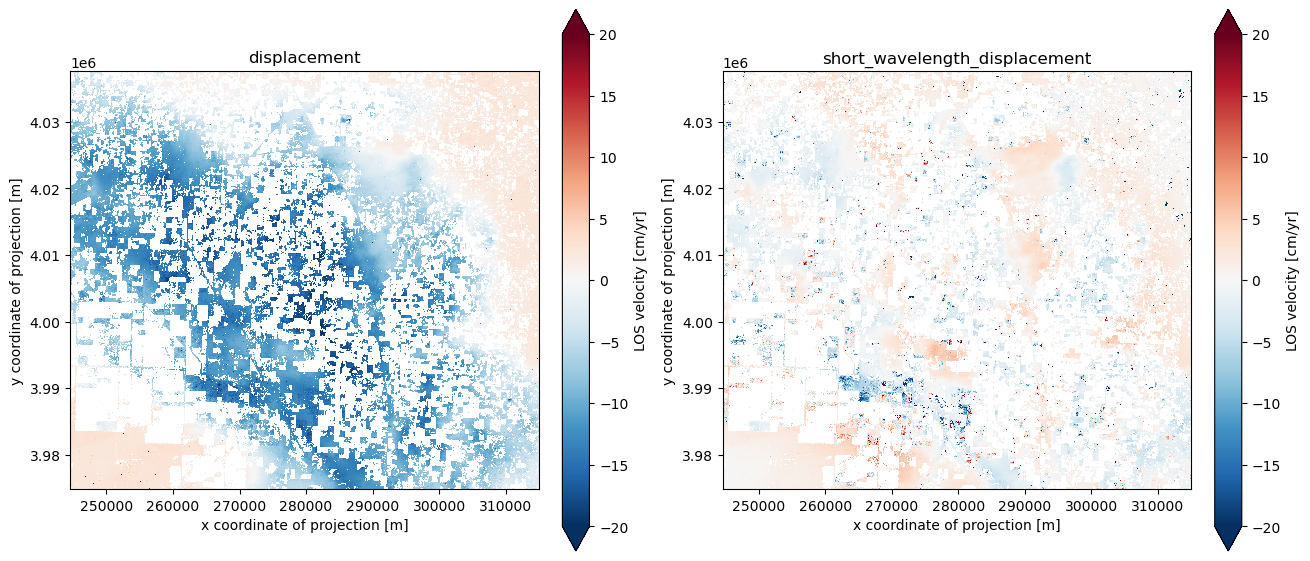

In [9]:
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import xarray as xr  # noqa: E402

ds = xr.open_dataset("corcoran-stack.nc")
years = (ds.time - ds.time[0]) / np.timedelta64(365, "D")

velocities = {}
for name in ("displacement", "short_wavelength_displacement"):
    da = ds[name].where(ds.recommended_mask.isel(time=-1) == 1)
    fit = da.assign_coords(time=years).polyfit("time", deg=1)
    velocities[name] = fit.polyfit_coefficients.sel(degree=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
for ax, (name, vel) in zip(axes, velocities.items()):
    vel.plot.imshow(
        ax=ax,
        cmap="RdBu_r",
        vmin=-20,
        vmax=20,
        cbar_kwargs={"label": "LOS velocity [cm/yr]"},
    )
    ax.set_aspect("equal")
    ax.set_title(name)

### Homework write up

1. Where do the full and short-wavelength results agree, and where do they diverge? Relate the broad differences to the 30 km high-pass filter.
2. The portal's Basic Velocity currently uses the full available record and clips the map display to +/-0.03 m/yr. This notebook uses 2020-2024. How can the date window and display range affect a visual comparison?
3. The full-displacement stack requires a spatial reference. The portal's short-wavelength layer has no single spatial reference point. Explain why this may be a valid choice in some cases (hint: EGMS describes a similar process in its ATBD as a "virtual reference")
4. Pick a portal pixel and plot the same location from `timeseries.h5`. Compare the time-dependent shape, the absolute value, and note any quality-mask gaps.